In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# just to make the plots look a bit nicer
sns.set_style("whitegrid")


In [2]:
iris = sns.load_dataset("iris")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# basic info about the dataset
iris.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
iris.describe()


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
# how many flowers of each species
iris['species'].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

mean_values = iris[numeric_cols].mean()
print("Mean values:\n", mean_values)


Mean values:
 sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64


In [7]:
median_values = iris[numeric_cols].median()
print("Median values:\n", median_values)


Median values:
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64


In [8]:
# mode can have more than one value so using scipy
mode_values = iris[numeric_cols].mode()
print("Mode values:")
mode_values


Mode values:


,sepal_length,sepal_width,petal_length,petal_width
0,5.0,3.0,1.4,0.2
1,NaN,NaN,1.5,NaN


In [9]:
# putting all three together in one table for easy comparison
central_tendency = pd.DataFrame({
    'Mean': iris[numeric_cols].mean(),
    'Median': iris[numeric_cols].median(),
    'Mode': iris[numeric_cols].mode().iloc[0]
})
central_tendency


,Mean,Median,Mode
sepal_length,5.843333,5.80,5.0
sepal_width,3.057333,3.00,3.0
petal_length,3.758000,4.35,1.4
petal_width,1.199333,1.30,0.2


In [10]:
range_values = iris[numeric_cols].max() - iris[numeric_cols].min()
print("Range:\n", range_values)


Range:
 sepal_length    3.6
sepal_width     2.4
petal_length    5.9
petal_width     2.4
dtype: float64


In [11]:
variance_values = iris[numeric_cols].var()
print("Variance:\n", variance_values)


Variance:
 sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64


In [12]:
std_values = iris[numeric_cols].std()
print("Standard Deviation:\n", std_values)


Standard Deviation:
 sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64


In [13]:
dispersion = pd.DataFrame({
    'Range': range_values,
    'Variance': variance_values,
    'Std Dev': std_values
})
dispersion


,Range,Variance,Std Dev
sepal_length,3.6,0.685694,0.828066
sepal_width,2.4,0.189979,0.435866
petal_length,5.9,3.116278,1.765298
petal_width,2.4,0.581006,0.762238


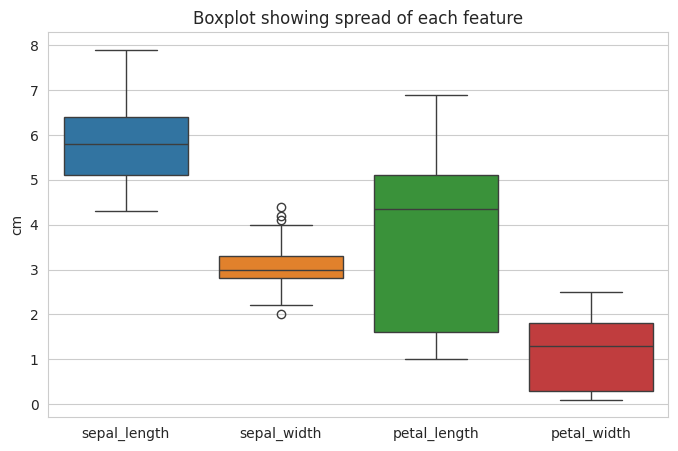

In [14]:
# quick boxplot to visually see the spread of each feature
plt.figure(figsize=(8,5))
sns.boxplot(data=iris[numeric_cols])
plt.title("Boxplot showing spread of each feature")
plt.ylabel("cm")
plt.show()


In [15]:
cov_matrix = iris[numeric_cols].cov()
print("Covariance Matrix:")
cov_matrix


Covariance Matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [16]:
corr_matrix = iris[numeric_cols].corr()
print("Correlation Matrix (Pearson):")
corr_matrix


Correlation Matrix (Pearson):


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [17]:
# checking correlation between just two columns as an example
r, p_value = stats.pearsonr(iris['petal_length'], iris['petal_width'])
print(f"Correlation between petal length and petal width: {r:.3f}")
print(f"p-value: {p_value:.5f}")


Correlation between petal length and petal width: 0.963
p-value: 0.00000


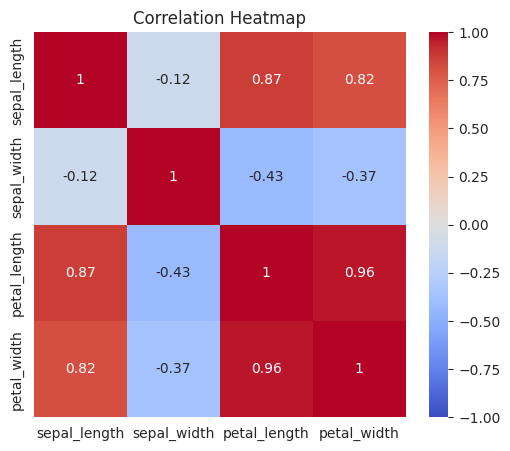

In [18]:
# heatmap of correlation matrix
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()


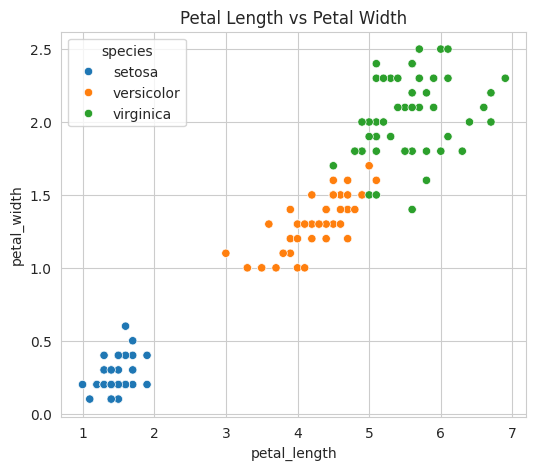

In [19]:
# scatter plot to visualize correlation between petal length and petal width
plt.figure(figsize=(6,5))
sns.scatterplot(data=iris, x='petal_length', y='petal_width', hue='species')
plt.title("Petal Length vs Petal Width")
plt.show()


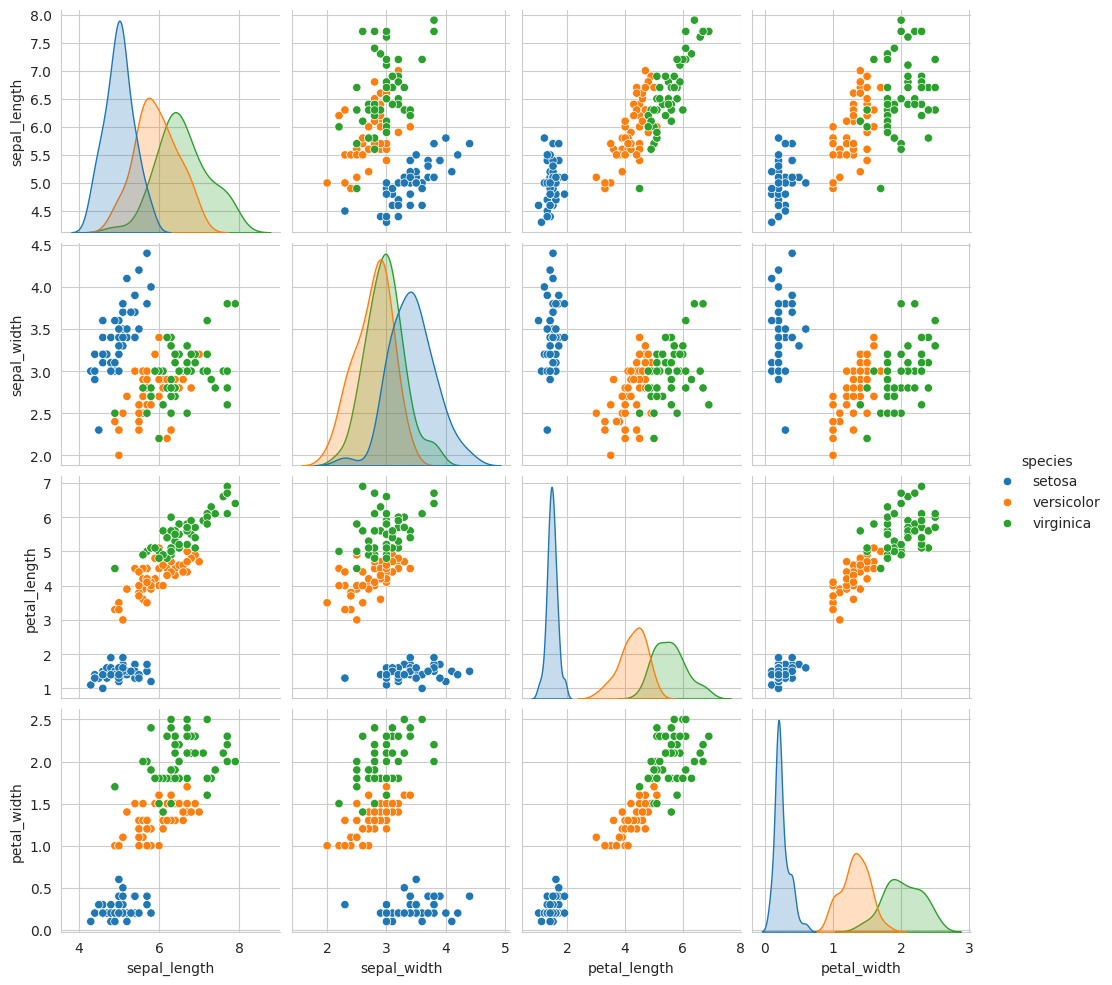

In [20]:
# pairplot to see correlation between all features at once, colored by species
sns.pairplot(iris, hue='species')
plt.show()
